## Transition Probability for the Ramp Model

### 1. Without Boundary Condition

The ramp model update rule is:

$$
x_{t+1} = x_t + \beta \, dt + \sigma \sqrt{dt} \, \epsilon_t, \quad \epsilon_t \sim \mathcal{N}(0, 1)
$$

So the conditional distribution of $x_{t+1}$ given $x_t$ is:

$$
x_{t+1} \mid x_t \sim \mathcal{N}(x_t + \beta dt,\; \sigma^2 dt)
$$

And the transition probability density is:

$$
P(x_{t+1} \mid x_t) = \frac{1}{\sqrt{2\pi \sigma^2 dt}} \exp\left( -\frac{(x_{t+1} - x_t - \beta dt)^2}{2\sigma^2 dt} \right)
$$

(Same as parker so far)

---

### 2. With Boundary Condition at $x = 0$

Now we enforce that $x_t \geq 0$ always. If a proposed update takes $x_t$ below 0, it is instead clipped at 0:

$$
x_{t+1} = \max\left(0,\; x_t + \beta dt + \sigma \sqrt{dt} \, \epsilon_t \right)
$$

i.e.

$$
x_{t+1} = \max\left(0,\; x_{t+1} \right)
$$

This modifies the transition distribution:

---

#### Case A: $x_t > 0$

We still use the normal distribution:


$$
x_{t+1} \mid x_t > 0 \sim \mathcal{N}(x_t + \beta dt,\; \sigma^2 dt)
$$

But to strictly enforce $x_{t+1} \geq 0$, we redefine it as a **truncated Gaussian** on $x > 0$, plus a point mass at 0:

- Probability of hitting zero:

$$
P(x_{t+1} = 0 \mid x_t) = \Phi\left( -\frac{x_t + \beta dt}{\sigma \sqrt{dt}} \right)
$$

- Density for $x_{t+1} > 0$:

$$
P(x_{t+1} = x \mid x_t,\; x > 0) = \frac{1}{\sigma \sqrt{2\pi dt}} \cdot \frac{\exp\left(-\frac{(x - x_t - \beta dt)^2}{2 \sigma^2 dt}\right)}{1 - \Phi\left(-\frac{x_t + \beta dt}{\sigma \sqrt{dt}} \right)}
$$

---

#### Case B: $x_t = 0$

Now the process starts at the boundary. Define:

$$
\mu = \beta dt, \quad \sigma^2 = \sigma^2 dt
$$

Let $Z \sim \mathcal{N}(\mu, \sigma^2)$. Then:

- Probability of remaining at zero:

$$
P(x_{t+1} = 0 \mid x_t = 0) = \Phi\left( -\frac{\mu}{\sigma} \right) = \Phi\left( -\frac{\beta \sqrt{dt}}{\sigma} \right)
$$

- Probability density for $x_{t+1} > 0$:

$$
P(x_{t+1} = x \mid x_t = 0, x > 0) = \frac{1}{\sigma \sqrt{2\pi dt}} \cdot \frac{\exp\left( -\frac{(x - \beta dt)^2}{2\sigma^2 dt} \right)}{\Phi\left( \frac{\beta \sqrt{dt}}{\sigma} \right)}
$$

This is a **truncated Gaussian** distribution, normalized over the positive half-line, with a point mass at 0.

$$
P(x_{t+1}|x_t) = \begin{cases}P(x_{t+1} = x \mid x_t = 0) = \frac{1}{\sigma \sqrt{2\pi dt}} \cdot \exp\left( -\frac{(x - \beta dt)^2}{2\sigma^2 dt} \right) & \text{if } x > 0 \\
P(x_{t+1} = 0 \mid x_t = 0) = \Phi\left( -\frac{\mu}{\sigma} \right) = \Phi\left( -\frac{\beta \sqrt{dt}}{\sigma} \right) & \text{if } x_t=0 \text{ and } x_t \geq 0 \\
0 & \text{if } x_{t+1} < 0
\end{cases}
$$
---

### Summary

The full transition probability with boundary at $x = 0$ is a **mixture of**:
- A **point mass at 0**: if the noise would push $x_{t+1}$ negative,
- A **truncated Gaussian**: if the proposed update remains positive,

This ensures that $x_t \geq 0$ for all $t$, while preserving the original stochastic ramp dynamics.


### Integral Form of the Cumulative Distribution Function

For full form of the stuff above, the standard Gaussian CDF is:

$$
\Phi(z) = \int_{-\infty}^{z} \frac{1}{\sqrt{2\pi}} \, e^{-u^2/2} \, du
$$

#### For the transition probability:

When $ x_t > 0 $, the probability that the proposed update falls below 0 (and is thus clipped) is:

$$
P(x_{t+1} = 0 \mid x_t) = \Phi\left( -\frac{x_t + \beta dt}{\sigma \sqrt{dt}} \right) 
= \int_{-\infty}^{-\frac{x_t + \beta dt}{\sigma \sqrt{dt}}} \frac{1}{\sqrt{2\pi}} e^{-u^2/2} \, du
$$

#### When $ x_t = 0 $ :

Then the probability that $ x_{t+1} = 0 $ (i.e., that the Gaussian sample is negative) becomes:

$$
P(x_{t+1} = 0 \mid x_t = 0) = \Phi\left( -\frac{\beta \sqrt{dt}}{\sigma} \right)
= \int_{-\infty}^{-\frac{\beta \sqrt{dt}}{\sigma}} \frac{1}{\sqrt{2\pi}} e^{-u^2/2} \, du
$$

This is the same as $ x_t > 0 $ just good to highlight. When $ x_t > 0 $, due to the variance relying on $dt$, which is small, we may not need to consider the truncated part of the distribution, as it is likely far enough away to have an effect.

### Transition Probabilities $P(x_{t+1} \mid x_t)$

Let:
- $\mu = x_t + \beta \, dt$
- $\sigma^2 = \sigma^2 \, dt$
- $\phi(x; \mu, \sigma^2)$: Gaussian PDF with mean $\mu$, variance $\sigma^2$
- $\Phi(0; \mu, \sigma^2)$: Gaussian CDF evaluated at 0

Then:

$$
P(x_{t+1} \mid x_t) =
\begin{cases}
\Phi(0; \beta dt, \sigma^2 dt) \cdot \delta(x_{t+1}) + \dfrac{\phi(x_{t+1}; \beta dt, \sigma^2 dt)}{1 - \Phi(0; \beta dt, \sigma^2 dt)} \cdot \mathbb{1}_{x_{t+1} > 0} & \text{if } x_t = 0 \\\\
\phi(x_{t+1}; x_t + \beta dt, \sigma^2 dt) & \text{if } x_t > 0
\end{cases}
$$

where

$$
\mathbb{1}_{x_{t+1} > 0} = 
\begin{cases}
1 & \text{if } x_{t+1} > 0 \\
0 & \text{otherwise}
\end{cases}
$$

It **equals 1 when the condition is true** and **0 otherwise**.

**Interpretation**:
- If $x_t = 0$: 
  - There is a point mass at $x_{t+1} = 0$ with probability $\Phi(0; \beta dt, \sigma^2 dt)$
  - The rest is a truncated Gaussian over $x_{t+1} > 0$
- If $x_t > 0$: 
  - The update is a standard Gaussian with mean $x_t + \beta dt$ and variance $\sigma^2 dt$
- If accuracy is required over coding simplicity, we can ignore the $x_t > 0$ case and just say for all $x_t \geq 0$


### Implementing absorbing boundary condition ###

As when $x_t$ = 1 it stays there, we need to also account for this

$$
P(x_{t+1} \mid x_t) =
\begin{cases}
\delta(x_{t+1} - 1) & \text{if } x_t = 1 \\
\\
\Phi(0; \mu, \sigma^2) \cdot \delta(x_{t+1}) + \left[ \dfrac{\phi(x_{t+1}; \mu, \sigma^2)}{\Phi(1; \mu, \sigma^2) - \Phi(0; \mu, \sigma^2)} \right] \cdot \mathbb{1}_{(0 < x_{t+1} < 1)} + (1 - \Phi(1; \mu, \sigma^2)) \cdot \delta(x_{t+1} - 1) & \text{if } x_t = 0 \\
\\
\left[ \dfrac{\phi(x_{t+1}; \mu, \sigma^2)}{\Phi(1; \mu, \sigma^2) - \Phi(0; \mu, \sigma^2)} \right] \cdot \mathbb{1}_{(0 < x_{t+1} < 1)} + \Phi(0; \mu, \sigma^2) \cdot \delta(x_{t+1}) + (1 - \Phi(1; \mu, \sigma^2)) \cdot \delta(x_{t+1} - 1) & \text{if } 0 < x_t < 1 \\
\end{cases}
$$


# Task 2.1 Plan: Forming an HMM Approximation to the Ramp Model

This plan outlines the steps to approximate the continuous ramp model using a discrete-state Hidden Markov Model (HMM).

---

## 1. Understand the Continuous Model

We start with the continuous update rule:

$$
x_{t+1} = x_t + \beta\,dt + \sigma\sqrt{dt}\,\epsilon_t, \quad \epsilon_t \sim \mathcal{N}(0,1)
$$

### Boundary Conditions:
- Reflecting at $x = 0$: If a negative update would take $x_t < 0$, we clamp it to zero.
- Absorbing at $x = 1$: Once $x_t = 1$, it stays there forever.

---

## 2. Discretize the State Space

Discretize $x \in [0, 1]$ into $K$ evenly spaced points:

```python
K = 100
x_vals = np.linspace(0, 1, K)
```

Each state index $s \in \{0, \ldots, K-1\}$ corresponds to:

$$
x_s = \frac{s}{K-1}
$$

---

## 3. Build the Transition Matrix $\mathcal{T}_{s,s'}$

For each pair $(s, s')$:

1. Compute the mean and standard deviation:

$$
\mu = x_s + \beta\,dt, \quad \text{std} = \sigma\sqrt{dt}
$$

2. Define bin width:

$$
\delta = \frac{1}{K-1}
$$

3. Compute transition probabilities using the Gaussian CDF:

$$
\mathcal{T}_{s, s'} = \int_{x_{s'} - \delta/2}^{x_{s'} + \delta/2} \mathcal{N}(x; \mu, \sigma^2 dt)\,dx
$$

### Special Cases:
- **Reflecting at 0**:

$$
\mathcal{T}_{0, 0} += \int_{-\infty}^{0} \mathcal{N}(x; \mu, \sigma^2 dt)\,dx
$$

- **Absorbing at 1**:

$$
\mathcal{T}_{K-1, K-1} = 1, \quad \mathcal{T}_{K-1, s'} = 0 \text{ for } s' \ne K-1
$$

---

## 4. Normalize Rows

Ensure each row of $\mathcal{T}$ sums to 1:

```python
T = T / T.sum(axis=1, keepdims=True)
```

For numerical stability (if needed), compute in log-space using `scipy.special.logsumexp`.

---

## 5. Construct the Initial Distribution $\pi$

Given:

$$
x_0 = x_{\text{init}} + \sigma\sqrt{dt} \epsilon_0
$$

Create a Gaussian over the $x$-grid:

```python
pi = norm.pdf(x_vals, loc=x_init, scale=sigma * np.sqrt(dt))
pi /= pi.sum()
```

---

## 6. Simulate the Markov Chain

1. Draw initial state:

```python
s_0 = np.random.choice(K, p=pi)
```

2. Iterate:

```python
s_t = np.random.choice(K, p=T[s_prev])
x_t = x_vals[s_t]
```

3. Repeat for desired number of time steps.

---

## 7. Compute Firing Rate

Map $x_t$ to firing rate:

$$
r_t = r_0 + (r_{\text{max}} - r_0)x_t
$$

Compare to continuous ramp model’s firing rate to validate approximation.

---

## 8. Check for Stuck Trajectories

If $\sigma$ is too small (especially when $\beta = 0$), updates may not be large enough to change state.

Estimate the threshold:

$$
\sigma_{\text{min}} \sim \frac{\delta}{\sqrt{dt}} = \frac{1}{(K - 1)\sqrt{dt}}
$$

Use values of $\sigma$ above this threshold unless instructed otherwise.

---

## Summary

By following these steps, you will:

- Discretize the latent space of the ramp model
- Form an HMM transition matrix under boundary constraints
- Simulate HMM trajectories and compare them to the original model
- Analyze how model parameters affect dynamics and convergence

```python
# Optional: numpy/sciPy tools you'll use
import numpy as np
from scipy.stats import norm
from scipy.special import logsumexp
```


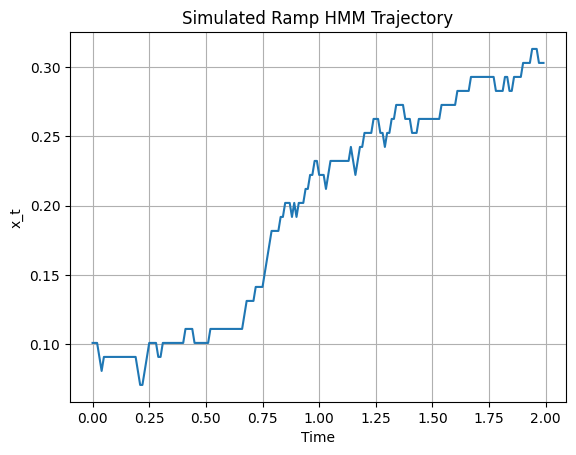

In [1]:
import numpy as np
from scipy.stats import norm
from scipy.special import logsumexp
import matplotlib.pyplot as plt

class DiscreteRampHMM:
    def __init__(self, beta, sigma, dt, K=100, x_init=0.0):
        self.beta = beta
        self.sigma = sigma
        self.dt = dt
        self.K = K
        self.x_vals = np.linspace(0, 1, K)
        self.dx = 1 / (K - 1)
        self.x_init = x_init

        self.T = self._build_transition_matrix()
        self.pi = self._build_initial_distribution()

    def _build_transition_matrix(self):
        T = np.zeros((self.K, self.K))

        for s in range(self.K):
            mu = self.x_vals[s] + self.beta * self.dt
            std = self.sigma * np.sqrt(self.dt)

            for s_prime in range(self.K):
                lower = self.x_vals[s_prime] - self.dx / 2
                upper = self.x_vals[s_prime] + self.dx / 2
                T[s, s_prime] = norm.cdf(upper, mu, std) - norm.cdf(lower, mu, std)

            # Reflecting boundary at 0
            if s == 0:
                T[s, 0] += norm.cdf(0, mu, std)

            # Absorbing boundary at 1
            if s == self.K - 1:
                T[s, :] = 0
                T[s, self.K - 1] = 1.0

            # Normalize row
            T[s, :] /= T[s, :].sum()

        return T

    def _build_initial_distribution(self):
        std = self.sigma * np.sqrt(self.dt)
        pi = norm.pdf(self.x_vals, loc=self.x_init, scale=std)
        pi /= pi.sum()
        return pi

    def simulate(self, T_steps=100):
        states = np.zeros(T_steps, dtype=int)
        x_t = np.zeros(T_steps)

        states[0] = np.random.choice(self.K, p=self.pi)
        x_t[0] = self.x_vals[states[0]]

        for t in range(1, T_steps):
            states[t] = np.random.choice(self.K, p=self.T[states[t-1]])
            x_t[t] = self.x_vals[states[t]]

        return x_t

    def plot_trajectory(self, x_t):
        plt.plot(np.arange(len(x_t)) * self.dt, x_t)
        plt.xlabel("Time")
        plt.ylabel("x_t")
        plt.title("Simulated Ramp HMM Trajectory")
        plt.grid(True)
        plt.show()

# Example usage:
if __name__ == "__main__":
    model = DiscreteRampHMM(beta=0.1, sigma=0.05, dt=0.01, K=100, x_init=0.1)
    trajectory = model.simulate(T_steps=200)
    model.plot_trajectory(trajectory)
